In [20]:
## Libraries

import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
from fredapi import Fred

import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(
    "../data/processed/quarterly_llp_macro.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,llp,unemployment,indpro,recession,term_spread
DATE,,,,,
1984-01-01,2142.141,7.866667,53.341067,0.0,2.408710
1984-04-01,3565.992,7.433333,54.171333,0.0,3.026032
1984-07-01,3367.472,7.433333,54.535667,0.0,2.127460
1984-10-01,4888.653,7.300000,54.568733,0.0,2.595738
1985-01-01,3019.247,7.233333,54.760000,0.0,3.121833


In [5]:
# Sanity check

df.index.min(), df.index.max(), len(df)

(Timestamp('1984-01-01 00:00:00'), Timestamp('2025-07-01 00:00:00'), 167)

In [6]:
df["dllp"] = df["llp"].diff()
df["dunemp"] = df["unemployment"].diff()
df["dspread"] = df["term_spread"].diff()
df["dindpro"] = df["indpro"].diff()

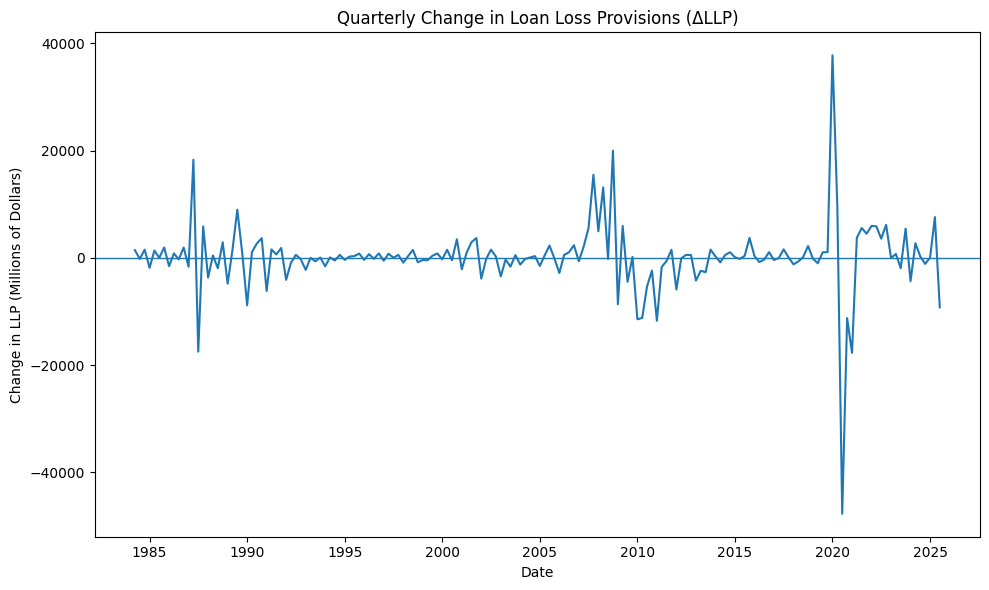

In [7]:
# Delta LLP Plot

plt.figure(figsize=(10,6))
plt.plot(df.index, df["dllp"])
plt.title("Quarterly Change in Loan Loss Provisions (ΔLLP)")
plt.ylabel("Change in LLP (Millions of Dollars)")
plt.xlabel("Date")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

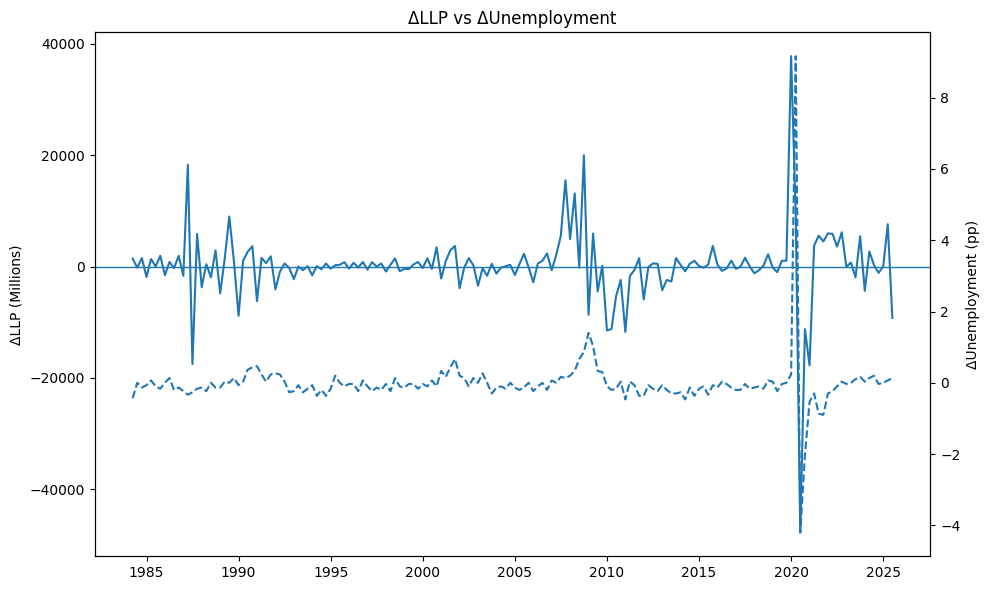

In [9]:
# Overlay Delta LLP onto Delta Unemployment

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(df.index, df["dllp"])
ax1.set_ylabel("ΔLLP (Millions)")
ax1.axhline(0, linewidth=1)

ax2 = ax1.twinx()
ax2.plot(df.index, df["dunemp"], linestyle="--")
ax2.set_ylabel("ΔUnemployment (pp)")

plt.title("ΔLLP vs ΔUnemployment")
plt.tight_layout()
plt.show()

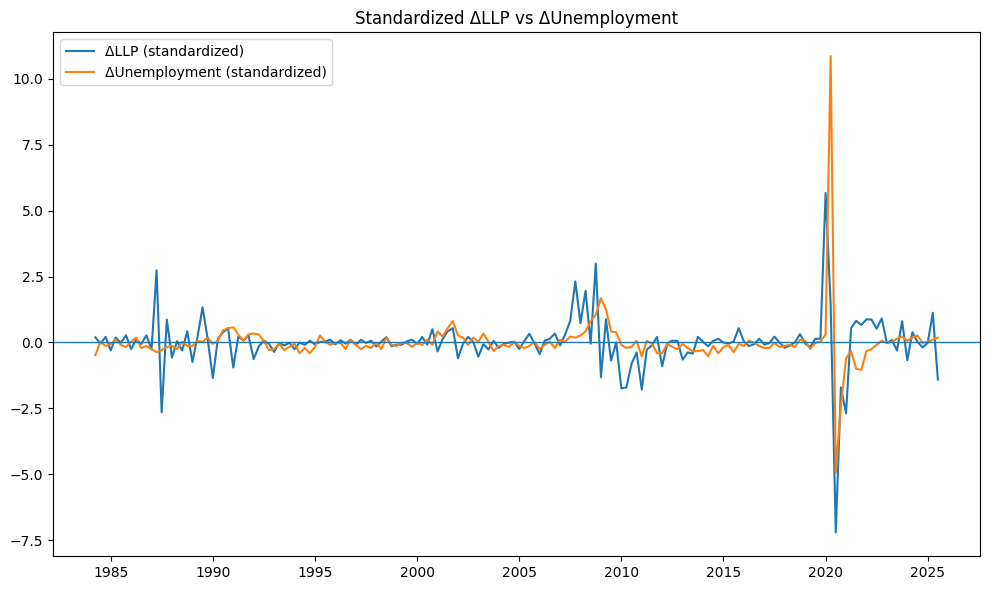

In [10]:
# Create Z Scores

df["dllp_z"] = (df["dllp"] - df["dllp"].mean()) / df["dllp"].std()
df["dunemp_z"] = (df["dunemp"] - df["dunemp"].mean()) / df["dunemp"].std()

# More readable plot

plt.figure(figsize=(10,6))
plt.plot(df.index, df["dllp_z"], label="ΔLLP (standardized)")
plt.plot(df.index, df["dunemp_z"], label="ΔUnemployment (standardized)")
plt.axhline(0, linewidth=1)
plt.legend()
plt.title("Standardized ΔLLP vs ΔUnemployment")
plt.tight_layout()
plt.show()

In [11]:
df_cc = df[["dllp", "dunemp"]].dropna()

In [12]:
# Cross-correlations

max_lag = 8
lags = range(-max_lag, max_lag + 1)

correlations = []

for k in lags:
    if k > 0:
        corr = df_cc["dllp"].corr(df_cc["dunemp"].shift(-k))
    elif k < 0:
        corr = df_cc["dllp"].shift(k).corr(df_cc["dunemp"])
    else:
        corr = df_cc["dllp"].corr(df_cc["dunemp"])
    
    correlations.append(corr)

ccf_df = pd.DataFrame({
    "lag": list(lags),
    "correlation": correlations
})

In [14]:
peak_row = ccf_df.loc[ccf_df["correlation"].abs().idxmax()]

print("Peak lag:", peak_row["lag"])
print("Peak correlation:", peak_row["correlation"])

ccf_df.reindex(ccf_df["correlation"].abs().sort_values(ascending=False).index).head()

Peak lag: 1.0
Peak correlation: 0.48776381772792554


,lag,correlation
9,1,0.487764
7,-1,-0.381794
8,0,0.373802
5,-3,-0.244908
10,2,-0.089015


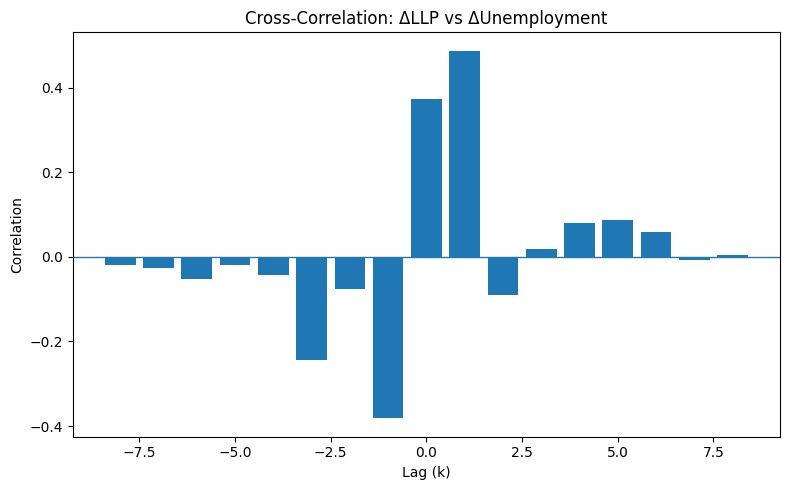

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(ccf_df["lag"], ccf_df["correlation"])
plt.axhline(0, linewidth=1)
plt.title("Cross-Correlation: ΔLLP vs ΔUnemployment")
plt.xlabel("Lag (k)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

In [16]:
peak_row = ccf_df.loc[ccf_df["correlation"].abs().idxmax()]

print("Peak lag:", peak_row["lag"])
print("Peak correlation:", peak_row["correlation"])

Peak lag: 1.0
Peak correlation: 0.48776381772792554


In [17]:
# Create lags


for k in range(0, 5):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)

In [18]:
# Regression dataset

reg_cols = ["dllp"] + [f"dunemp_lag{k}" for k in range(0,5)]

df_reg = df[reg_cols].dropna()

In [19]:
df_reg.head()
df_reg.shape

(162, 6)

In [21]:
X = df_reg[[f"dunemp_lag{k}" for k in range(0,5)]]
X = sm.add_constant(X)

y = df_reg["dllp"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   dllp   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     17.74
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           6.70e-14
Time:                        22:33:40   Log-Likelihood:                -1620.5
No. Observations:                 162   AIC:                             3253.
Df Residuals:                     156   BIC:                             3271.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.1269    428.869     -0.007      

In [22]:
model_robust = sm.OLS(y, X).fit(cov_type="HC1")
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   dllp   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     9.495
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           6.36e-08
Time:                        22:35:11   Log-Likelihood:                -1620.5
No. Observations:                 162   AIC:                             3253.
Df Residuals:                     156   BIC:                             3271.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.1269    443.224     -0.007      

In [23]:
sum(model_robust.params[1:])

-5329.757991658504